Using data dir: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge
train: (138701, 50) test: (15000, 49)
Test rows with asset resale history:  2107 / 15000
Test rows with config resale history: 14612 / 15000
count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64
Skew (raw): 0.9699963984208283
Skew (log1p): -0.19830390386050994


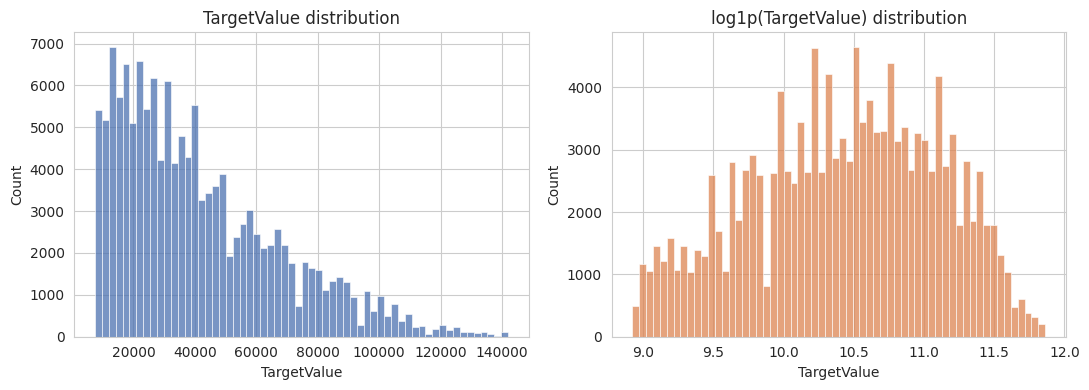

Num features: 30, Cat features: 40
Feature count before target encoding: 110
Target-encoding 9 high-cardinality cols; label-encoding 31 low-cardinality cols
High-cardinality cols: ['ProductConfigID', 'VendorPartnerID', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'FunctionalClassification', 'RegionCode']
Final feature count: 110
{
  "Ridge Regression": {
    "RMSLE": 0.2673159563232295,
    "R2": 0.8140944622654097
  },
  "Random Forest": {
    "RMSLE": 0.2270050151327307,
    "R2": 0.874350336149982
  }
}

Where the new features rank overall (lower rank = more important):
  col21_num                        rank 58/110  importance=0.0002
  col15_num                        rank 56/110  importance=0.0003
  col7_num                         rank 74/110  importance=0.0001
  col22_num                        rank 50/110  importance=0.0003
  asset_prior_avg_price_log        rank 42/110  importance=0.0006
  asset_prior_last_price_log   

  0%|          | 0/20 [00:00<?, ?it/s]

HistGB: best CV RMSLE=0.2103  (843s, 20 trials)
  params: {'max_iter': 453, 'max_depth': 9, 'learning_rate': 0.13181385673064763, 'l2_regularization': 0.015380405247172551, 'max_leaf_nodes': 106, 'min_samples_leaf': 76}


  0%|          | 0/20 [00:00<?, ?it/s]

LightGBM: best CV RMSLE=0.2077  (673s, 20 trials)
  params: {'n_estimators': 696, 'max_depth': 11, 'num_leaves': 248, 'learning_rate': 0.07277037581026281, 'reg_alpha': 0.062257578888456615, 'reg_lambda': 0.0040243589601681815, 'min_child_samples': 35, 'subsample': 0.722497702919922, 'colsample_bytree': 0.8786911382357088}


  0%|          | 0/20 [00:00<?, ?it/s]

CatBoost: best CV RMSLE=0.2086  (1928s, 20 trials)
  params: {'iterations': 967, 'depth': 8, 'learning_rate': 0.13812240169527853, 'l2_leaf_reg': 1.0422259339479674, 'bagging_temperature': 1.303733101556357, 'random_strength': 0.6742633998253229}


  0%|          | 0/20 [00:00<?, ?it/s]

XGBoost: best CV RMSLE=0.2068  (1003s, 20 trials)
  params: {'n_estimators': 792, 'max_depth': 10, 'learning_rate': 0.03325900508660439, 'reg_alpha': 0.21522572686276525, 'reg_lambda': 1.1828474104136515, 'min_child_weight': 7, 'subsample': 0.7770883675786787, 'colsample_bytree': 0.6139954304802397}
HistGB: OOF RMSLE=0.2085  (96s)
LightGBM: OOF RMSLE=0.2057  (123s)
0:	learn: 0.5995676	total: 44.5ms	remaining: 43s
1:	learn: 0.5390185	total: 91.2ms	remaining: 44s
2:	learn: 0.4870575	total: 154ms	remaining: 49.6s
3:	learn: 0.4439860	total: 215ms	remaining: 51.8s
4:	learn: 0.4081798	total: 265ms	remaining: 51s
5:	learn: 0.3786892	total: 309ms	remaining: 49.5s
6:	learn: 0.3547339	total: 353ms	remaining: 48.4s
7:	learn: 0.3353604	total: 400ms	remaining: 47.9s
8:	learn: 0.3192918	total: 439ms	remaining: 46.7s
9:	learn: 0.3062971	total: 480ms	remaining: 45.9s
10:	learn: 0.2957544	total: 520ms	remaining: 45.2s
11:	learn: 0.2873819	total: 563ms	remaining: 44.8s
12:	learn: 0.2800735	total: 604ms	

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, glob, re, warnings, time
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# ---- CELL: Setup & Load Data ----
candidates = glob.glob('/kaggle/input/**/train.csv', recursive=True)
assert candidates, "Could not find train.csv under /kaggle/input/. Set DATA_DIR manually."
DATA_DIR = candidates[0].rsplit('/', 1)[0]
print("Using data dir:", DATA_DIR)

train_raw = pd.read_csv(f'{DATA_DIR}/train.csv', low_memory=False)
test_raw  = pd.read_csv(f'{DATA_DIR}/test.csv', low_memory=False)
sub       = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print("train:", train_raw.shape, "test:", test_raw.shape)

TARGET = 'TargetValue'
ID_COL = 'TransactionID'


def build_group_history(id_col, group_col, extra_cols=()):
    """Leak-safe expanding mean/last/count for `group_col`, computed on a
    combined train+test frame sorted by date. Fully vectorized (no per-group
    Python loops or .apply()), so it stays fast even when `group_col` has
    tens of thousands of near-unique groups (e.g. AssetID)."""
    cols = ['TransactionDate', ID_COL, group_col] + list(extra_cols)
    combo = pd.concat([
        train_raw[cols].assign(target=np.log1p(train_raw[TARGET].values), is_train=1),
        test_raw[cols].assign(target=np.nan, is_train=0)
    ], ignore_index=True)
    combo['TransactionDate'] = pd.to_datetime(combo['TransactionDate'])
    combo = combo.sort_values([group_col, 'TransactionDate', ID_COL]).reset_index(drop=True)

    combo['target_filled'] = np.where(combo['is_train'] == 1, combo['target'], 0.0)
    combo['train_flag'] = combo['is_train'].astype(float)
    combo['cum_sum_incl'] = combo.groupby(group_col)['target_filled'].cumsum()
    combo['cum_cnt_incl'] = combo.groupby(group_col)['train_flag'].cumsum()
    prior_sum = combo['cum_sum_incl'] - combo['target_filled']
    prior_cnt = combo['cum_cnt_incl'] - combo['train_flag']

    prefix = id_col
    combo[f'{prefix}_prior_count'] = prior_cnt
    combo[f'{prefix}_prior_avg_price_log'] = prior_sum / prior_cnt.replace(0, np.nan)

    # last known (train) target / date, forward-filled then shifted by 1 within
    # each group so the current row never sees its own value.
    combo['known_val'] = combo['target'].where(combo['is_train'] == 1)
    combo['known_val_ffill'] = combo.groupby(group_col)['known_val'].ffill()
    combo[f'{prefix}_prior_last_price_log'] = combo.groupby(group_col)['known_val_ffill'].shift(1)

    combo['known_date'] = combo['TransactionDate'].where(combo['is_train'] == 1)
    combo['known_date_ffill'] = combo.groupby(group_col)['known_date'].ffill()
    prior_last_date = combo.groupby(group_col)['known_date_ffill'].shift(1)
    combo[f'{prefix}_days_since_last'] = (combo['TransactionDate'] - prior_last_date).dt.days

    out_cols = [f'{prefix}_prior_count', f'{prefix}_prior_avg_price_log',
                f'{prefix}_prior_last_price_log', f'{prefix}_days_since_last']
    return combo[[ID_COL] + out_cols].set_index(ID_COL), out_cols

asset_hist, asset_hist_cols = build_group_history('asset', 'AssetID')
config_hist, config_hist_cols = build_group_history('config', 'ProductConfigID')
class_hist, class_hist_cols = build_group_history('class', 'FunctionalClassification')

n_test_asset_hist = int((asset_hist.loc[test_raw[ID_COL], 'asset_prior_count'] > 0).sum())
n_test_config_hist = int((config_hist.loc[test_raw[ID_COL], 'config_prior_count'] > 0).sum())
print(f"Test rows with asset resale history:  {n_test_asset_hist} / {len(test_raw)}")
print(f"Test rows with config resale history: {n_test_config_hist} / {len(test_raw)}")


def build_recency_weighted_history(prefix, group_col, halflife_days=365):
    combo = pd.concat([
        train_raw[['TransactionDate', ID_COL, group_col]].assign(
            target=np.log1p(train_raw[TARGET].values), is_train=1),
        test_raw[['TransactionDate', ID_COL, group_col]].assign(target=np.nan, is_train=0)
    ], ignore_index=True)
    combo['TransactionDate'] = pd.to_datetime(combo['TransactionDate'])
    combo = combo.sort_values([group_col, 'TransactionDate', ID_COL]).reset_index(drop=True)

    n = len(combo)
    w_avg = np.full(n, np.nan)
    w_std = np.full(n, np.nan)
    group_ids = combo[group_col].values
    dates = combo['TransactionDate'].values
    targets = combo['target'].values
    is_train = combo['is_train'].values
    decay_lambda = np.log(2) / halflife_days

    start = 0
    for i in range(1, n + 1):
        if i == n or group_ids[i] != group_ids[start]:
            w_sum, wy_sum, wy2_sum, last_date = 0.0, 0.0, 0.0, None
            for j in range(start, i):
                if last_date is not None and w_sum > 0:
                    dt_days = (dates[j] - last_date) / np.timedelta64(1, 'D')
                    decay = np.exp(-decay_lambda * max(dt_days, 0))
                    cur_w, cur_wy, cur_wy2 = w_sum * decay, wy_sum * decay, wy2_sum * decay
                else:
                    cur_w, cur_wy, cur_wy2 = w_sum, wy_sum, wy2_sum
                if cur_w > 0:
                    mean_ = cur_wy / cur_w
                    w_avg[j] = mean_
                    w_std[j] = max(cur_wy2 / cur_w - mean_ ** 2, 0) ** 0.5
                if is_train[j] == 1:
                    w_sum, wy_sum, wy2_sum = cur_w, cur_wy, cur_wy2
                    w_sum += 1.0
                    wy_sum += targets[j]
                    wy2_sum += targets[j] ** 2
                    last_date = dates[j]
            start = i

    combo[f'{prefix}_recency_avg_price_log'] = w_avg
    combo[f'{prefix}_recency_std_price_log'] = w_std
    out_cols = [f'{prefix}_recency_avg_price_log', f'{prefix}_recency_std_price_log']
    return combo[[ID_COL] + out_cols].set_index(ID_COL), out_cols

config_recency, config_recency_cols = build_recency_weighted_history('config', 'ProductConfigID')
class_recency, class_recency_cols = build_recency_weighted_history('class', 'FunctionalClassification')

# Overall market trend (not grouped — one running average across all sales)
combo_mkt = pd.concat([
    train_raw[['TransactionDate', ID_COL]].assign(target=np.log1p(train_raw[TARGET].values), is_train=1),
    test_raw[['TransactionDate', ID_COL]].assign(target=np.nan, is_train=0)
], ignore_index=True)
combo_mkt['TransactionDate'] = pd.to_datetime(combo_mkt['TransactionDate'])
combo_mkt = combo_mkt.sort_values(['TransactionDate', ID_COL]).reset_index(drop=True)
combo_mkt['target_filled'] = np.where(combo_mkt['is_train'] == 1, combo_mkt['target'], 0.0)
combo_mkt['train_flag'] = combo_mkt['is_train'].astype(float)
combo_mkt['cum_sum'] = combo_mkt['target_filled'].cumsum()
combo_mkt['cum_cnt'] = combo_mkt['train_flag'].cumsum()
prior_sum = combo_mkt['cum_sum'] - combo_mkt['target_filled']
prior_cnt = combo_mkt['cum_cnt'] - combo_mkt['train_flag']
combo_mkt['market_trend_log'] = prior_sum / prior_cnt.replace(0, np.nan)
market_hist = combo_mkt[[ID_COL, 'market_trend_log']].set_index(ID_COL)

# ---- CELL: EDA / Statistics ----
desc = train_raw[TARGET].describe()
print(desc)
print("Skew (raw):", train_raw[TARGET].skew())
print("Skew (log1p):", np.log1p(train_raw[TARGET]).skew())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train_raw[TARGET], bins=60, color='#4C72B0', ax=axes[0])
axes[0].set_title('TargetValue distribution')
sns.histplot(np.log1p(train_raw[TARGET]), bins=60, color='#DD8452', ax=axes[1])
axes[1].set_title('log1p(TargetValue) distribution')
plt.tight_layout()
plt.show()

# ---- CELL: Feature Engineering ----
def parse_feet_inches(val):
    if pd.isna(val) or 'Unspecified' in str(val):
        return np.nan
    m = re.match(r"(\d+)'\s*(\d+)?", str(val))
    if not m:
        return np.nan
    feet = int(m.group(1))
    inches = int(m.group(2)) if m.group(2) else 0
    return feet * 12 + inches

def parse_feet(val):
    if pd.isna(val) or 'Unspecified' in str(val):
        return np.nan
    s = str(val).replace("'", "").replace('<', '').strip()
    try:
        return float(s) - (0.5 if '<' in str(val) else 0)
    except ValueError:
        return np.nan

def parse_inches(val):
    if pd.isna(val) or 'Unspecified' in str(val):
        return np.nan
    s = str(val).replace('inch', '').replace('"', '').strip()
    try:
        return float(s)
    except ValueError:
        return np.nan


FORCE_CATEGORICAL = ['ProductConfigID']

def feature_engineer(df):
    df = df.copy()
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['sale_year'] = df['TransactionDate'].dt.year
    df['sale_month'] = df['TransactionDate'].dt.month
    df['sale_quarter'] = df['TransactionDate'].dt.quarter
    df['sale_dayofyear'] = df['TransactionDate'].dt.dayofyear

    df.loc[df['ManufactureYear'] < 1900, 'ManufactureYear'] = np.nan
    df['equip_age'] = df['sale_year'] - df['ManufactureYear']
    df.loc[df['equip_age'] < 0, 'equip_age'] = np.nan

    df['log_hours'] = np.log1p(df['OperationalHoursMeter'].clip(lower=0))
    df['hours_per_year'] = df['OperationalHoursMeter'].clip(lower=0) / df['equip_age'].replace(0, np.nan)
    df['hours_per_year'] = df['hours_per_year'].replace([np.inf, -np.inf], np.nan).clip(upper=5000)

    if 'col21' in df.columns:
        df['col21_num'] = df['col21'].apply(parse_inches)
    if 'col15' in df.columns:
        df['col15_num'] = df['col15'].apply(parse_inches)
    if 'col7' in df.columns:
        df['col7_num'] = df['col7'].apply(parse_feet)
    if 'col22' in df.columns:
        df['col22_num'] = df['col22'].apply(parse_feet_inches)

    for c in FORCE_CATEGORICAL:
        if c in df.columns:
            df[c] = df[c].astype(str)

    df = df.drop(columns=['TransactionDate'])
    return df

train_fe = feature_engineer(train_raw)
test_fe  = feature_engineer(test_raw)

# attach all leak-safe historical features
for hist_df in [asset_hist, config_hist, class_hist, market_hist, config_recency, class_recency]:
    train_fe = train_fe.set_index(ID_COL).join(hist_df).reset_index()
    test_fe  = test_fe.set_index(ID_COL).join(hist_df).reset_index()

y = train_fe[TARGET].values
y_log = np.log1p(y)

parsed_source_cols = ['col21', 'col15', 'col7', 'col22']
drop_cols = [TARGET, ID_COL, 'AssetID'] + [c for c in parsed_source_cols if c in train_fe.columns]
feature_cols = [c for c in train_fe.columns if c not in drop_cols]

X_base = train_fe[feature_cols].copy()
X_test_base = test_fe[feature_cols].copy()

cat_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(X_base[c])]
num_cols = [c for c in feature_cols if c not in cat_cols]
print(f"Num features: {len(num_cols)}, Cat features: {len(cat_cols)}")

for c in cat_cols:
    X_base[c] = X_base[c].fillna('MISSING').astype(str)
    X_test_base[c] = X_test_base[c].fillna('MISSING').astype(str)

for c in cat_cols:
    freq = pd.concat([X_base[c], X_test_base[c]], axis=0).value_counts()
    X_base[f'{c}_freq'] = X_base[c].map(freq).fillna(0)
    X_test_base[f'{c}_freq'] = X_test_base[c].map(freq).fillna(0)

for c in num_cols:
    med = X_base[c].median()
    X_base[c] = X_base[c].fillna(med)
    X_test_base[c] = X_test_base[c].fillna(med)

print("Feature count before target encoding:", X_base.shape[1])

# ---- CELL: Out-of-Fold Target Encoding for categoricals ----
from sklearn.model_selection import KFold

N_FOLDS = 5
kf_te = KFold(n_splits=N_FOLDS, shuffle=True, random_state=1)
GLOBAL_MEAN = y_log.mean()
SMOOTHING = 20

def target_encode_oof(train_col, test_col, y_target, kf, global_mean, smoothing):
    oof = np.zeros(len(train_col))
    for tr_idx, va_idx in kf.split(train_col):
        tr_vals, va_vals = train_col.iloc[tr_idx], train_col.iloc[va_idx]
        tr_y = y_target[tr_idx]
        stats = pd.DataFrame({'cat': tr_vals, 'y': tr_y}).groupby('cat')['y'].agg(['mean', 'count'])
        smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        oof[va_idx] = va_vals.map(smoothed).fillna(global_mean).values

    stats_full = pd.DataFrame({'cat': train_col, 'y': y_target}).groupby('cat')['y'].agg(['mean', 'count'])
    smoothed_full = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) / (stats_full['count'] + smoothing)
    test_enc = test_col.map(smoothed_full).fillna(global_mean).values
    return oof, test_enc

X = X_base.copy()
X_test = X_test_base.copy()

cardinalities = {c: X_base[c].nunique() for c in cat_cols}
high_card_cols = [c for c, n_ in cardinalities.items() if n_ > 15]
low_card_cols = [c for c in cat_cols if c not in high_card_cols]
print(f"Target-encoding {len(high_card_cols)} high-cardinality cols; label-encoding {len(low_card_cols)} low-cardinality cols")
print("High-cardinality cols:", high_card_cols)

for c in high_card_cols:
    oof_enc, test_enc = target_encode_oof(X_base[c], X_test_base[c], y_log, kf_te, GLOBAL_MEAN, SMOOTHING)
    X[f'{c}_te'] = oof_enc
    X_test[f'{c}_te'] = test_enc
    X = X.drop(columns=[c])
    X_test = X_test.drop(columns=[c])

for c in low_card_cols:
    codes, _ = pd.factorize(pd.concat([X[c], X_test[c]], axis=0))
    n_train = len(X)
    X[c] = codes[:n_train]
    X_test[c] = codes[n_train:]

feature_cols = list(X.columns)
print("Final feature count:", X.shape[1])

# ---- CELL: Quick Baselines (Ridge, Random Forest) for reference ----
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

X_train, X_val, y_train_log, y_val_log, y_train, y_val = train_test_split(
    X, y_log, y, test_size=0.2, random_state=42
)

results = {}

scaler = StandardScaler()
ridge = Ridge(alpha=5.0, random_state=42)
ridge.fit(scaler.fit_transform(X_train), y_train_log)
pred_val = np.expm1(ridge.predict(scaler.transform(X_val)))
results['Ridge Regression'] = {'RMSLE': rmsle(y_val, pred_val), 'R2': r2_score(y_val, pred_val)}

rf = RandomForestRegressor(n_estimators=200, max_depth=18, min_samples_leaf=3, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train_log)
pred_val = np.expm1(rf.predict(X_val))
results['Random Forest'] = {'RMSLE': rmsle(y_val, pred_val), 'R2': r2_score(y_val, pred_val)}

print(json.dumps(results, indent=2))

new_feat_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nWhere the new features rank overall (lower rank = more important):")
watch_list = ['col21_num', 'col15_num', 'col7_num', 'col22_num',
              'asset_prior_avg_price_log', 'asset_prior_last_price_log', 'asset_prior_count',
              'config_prior_avg_price_log', 'config_prior_last_price_log', 'config_prior_count',
              'config_recency_avg_price_log', 'config_recency_std_price_log',
              'class_prior_avg_price_log', 'class_recency_avg_price_log',
              'market_trend_log', 'ProductConfigID_te']
for f in watch_list:
    if f in new_feat_importance.index:
        rank = list(new_feat_importance.index).index(f) + 1
        print(f"  {f:32s} rank {rank}/{len(new_feat_importance)}  importance={new_feat_importance[f]:.4f}")

# ---- CELL: Optuna tuning for 4 boosters (CV-based, pruned) ----
import optuna
from optuna.pruners import MedianPruner
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_FOLDS = 3
kf_tune = KFold(n_splits=TUNE_FOLDS, shuffle=True, random_state=42)

def cv_score(model_fn, params):
    scores = []
    for tr_idx, va_idx in kf_tune.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr = y_log[tr_idx]
        model = model_fn(params)
        model.fit(X_tr, y_tr)
        pred = np.expm1(model.predict(X_va))
        scores.append(rmsle(y[va_idx], pred))
    return np.mean(scores)

def hgb_objective(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 150, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 10.0, log=True),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 255),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 100),
        'random_state': 42,
    }
    return cv_score(lambda p: HistGradientBoostingRegressor(early_stopping=True, n_iter_no_change=20, **p), params)

def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbosity': -1,
    }
    return cv_score(lambda p: LGBMRegressor(**p), params)

def cb_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'random_strength': trial.suggest_float('random_strength', 0.5, 5.0),
        'random_seed': 42,
        'verbose': False,
    }
    return cv_score(lambda p: CatBoostRegressor(**p), params)

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbosity': 0,
    }
    return cv_score(lambda p: XGBRegressor(**p), params)

N_TRIALS = 20
tuned_params = {}
for name, obj_fn in [('HistGB', hgb_objective), ('LightGBM', lgb_objective),
                      ('CatBoost', cb_objective), ('XGBoost', xgb_objective)]:
    t0 = time.time()
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42),
                                 pruner=MedianPruner(n_warmup_steps=1))
    study.optimize(obj_fn, n_trials=N_TRIALS, show_progress_bar=True)
    tuned_params[name] = study.best_params
    print(f"{name}: best CV RMSLE={study.best_value:.4f}  ({time.time()-t0:.0f}s, {N_TRIALS} trials)")
    print(f"  params: {study.best_params}")

# ---- CELL: K-Fold Bagging for each tuned model (OOF + test predictions) ----
N_BAG_FOLDS = 5
kf_bag = KFold(n_splits=N_BAG_FOLDS, shuffle=True, random_state=7)

def bag_model(model_fn, name):
    oof = np.zeros(len(X))
    test_fold_preds = np.zeros((N_BAG_FOLDS, len(X_test)))
    t0 = time.time()
    for i, (tr_idx, va_idx) in enumerate(kf_bag.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr = y_log[tr_idx]
        model = model_fn()
        model.fit(X_tr, y_tr)
        oof[va_idx] = np.expm1(model.predict(X_va))
        test_fold_preds[i] = np.expm1(model.predict(X_test))
    test_pred = test_fold_preds.mean(axis=0)
    score = rmsle(y, oof)
    print(f"{name}: OOF RMSLE={score:.4f}  ({time.time()-t0:.0f}s)")
    return oof, test_pred, score

oof_hgb, test_hgb, score_hgb = bag_model(
    lambda: HistGradientBoostingRegressor(early_stopping=True, n_iter_no_change=20, **tuned_params['HistGB']), 'HistGB')
oof_lgb, test_lgb, score_lgb = bag_model(
    lambda: LGBMRegressor(**tuned_params['LightGBM']), 'LightGBM')
oof_cb, test_cb, score_cb = bag_model(
    lambda: CatBoostRegressor(**tuned_params['CatBoost']), 'CatBoost')
oof_xgb, test_xgb, score_xgb = bag_model(
    lambda: XGBRegressor(**tuned_params['XGBoost']), 'XGBoost')

results['HistGB (tuned, bagged)'] = {'RMSLE': score_hgb}
results['LightGBM (tuned, bagged)'] = {'RMSLE': score_lgb}
results['CatBoost (tuned, bagged)'] = {'RMSLE': score_cb}
results['XGBoost (tuned, bagged)'] = {'RMSLE': score_xgb}

# ---- CELL: Blend — linear weight search AND Ridge stacking, keep whichever is better ----
oof_matrix = np.vstack([oof_hgb, oof_lgb, oof_cb, oof_xgb]).T   # log-space? no — these are already price-space (expm1'd)
test_matrix = np.vstack([test_hgb, test_lgb, test_cb, test_xgb]).T

# work in log-space for the stacker/blend — squared-error-in-log-space is what RMSLE actually measures
oof_log_matrix = np.log1p(oof_matrix)
test_log_matrix = np.log1p(test_matrix)

def blend_loss(w):
    w = np.abs(w) / np.abs(w).sum()
    blended = oof_matrix @ w
    return rmsle(y, blended)

init_w = np.array([0.25, 0.25, 0.25, 0.25])
opt = minimize(blend_loss, init_w, method='Nelder-Mead')
best_w = np.abs(opt.x) / np.abs(opt.x).sum()
blended_oof_a = oof_matrix @ best_w
score_a = rmsle(y, blended_oof_a)


from sklearn.linear_model import Ridge as RidgeStacker
kf_stack = KFold(n_splits=5, shuffle=True, random_state=99)
stack_oof = np.zeros(len(y))
stack_models = []
for tr_idx, va_idx in kf_stack.split(oof_log_matrix):
    stacker = RidgeStacker(alpha=1.0, positive=True)  # positive=True keeps weights sensible/interpretable
    stacker.fit(oof_log_matrix[tr_idx], y_log[tr_idx])
    stack_oof[va_idx] = stacker.predict(oof_log_matrix[va_idx])
    stack_models.append(stacker)
blended_oof_b = np.expm1(stack_oof)
score_b = rmsle(y, blended_oof_b)

# final stacker refit on ALL oof predictions for use on the test set
final_stacker = RidgeStacker(alpha=1.0, positive=True)
final_stacker.fit(oof_log_matrix, y_log)

results['Weighted Blend (simplex)'] = {'RMSLE': score_a}
results['Ridge Stacking (log space)'] = {'RMSLE': score_b}

print(f"\nSimplex blend weights — HistGB: {best_w[0]:.3f}, LightGBM: {best_w[1]:.3f}, "
      f"CatBoost: {best_w[2]:.3f}, XGBoost: {best_w[3]:.3f}  -> OOF RMSLE {score_a:.4f}")
print(f"Ridge stacker coefficients — HistGB: {final_stacker.coef_[0]:.3f}, LightGBM: {final_stacker.coef_[1]:.3f}, "
      f"CatBoost: {final_stacker.coef_[2]:.3f}, XGBoost: {final_stacker.coef_[3]:.3f}, "
      f"intercept: {final_stacker.intercept_:.3f}  -> OOF RMSLE {score_b:.4f}")

print("\n=== Full model comparison (RMSLE, lower is better) ===")
for name, m in sorted(results.items(), key=lambda kv: kv[1]['RMSLE']):
    print(f"{name:42s} RMSLE={m['RMSLE']:.4f}")

use_stacking = score_b < score_a
print(f"\nUsing {'Ridge stacking' if use_stacking else 'simplex weight blend'} for the final submission "
      f"(OOF RMSLE {min(score_a, score_b):.4f})")

# ---- CELL: Final Prediction & Submission ----
if use_stacking:
    final_test_pred = np.expm1(final_stacker.predict(test_log_matrix))
    final_blend_score = score_b
else:
    final_test_pred = test_matrix @ best_w
    final_blend_score = score_a

final_test_pred = np.clip(final_test_pred, y.min(), y.max())

submission = pd.DataFrame({ID_COL: test_fe[ID_COL], TARGET: final_test_pred})
submission.to_csv('/kaggle/working/submission.csv', index=False)
print(submission.head())
print(f"\nSaved /kaggle/working/submission.csv (OOF RMSLE={final_blend_score:.4f})")